In [49]:
import pandas as pd
import matplotlib.pyplot as plt

# from rich import print

# def print(*o, sep=' ', end='\n', file=None, flush=False):
#     o = [str(x) for x in o]
#     p(*o, sep=sep, end=end, file=file, flush=flush)

# print.__doc__ = p.__doc__

In [50]:
dataset_path = "dataset/dataset-kcolor400.csv"
# dataset_path = "dataset/dataset-flat200.csv"
# dataset_path = "dataset/dataset-uf100-430.csv"
df = pd.read_csv(dataset_path)

# drop columns where all values are 0
for col in df.columns:
    if df[col].nunique() == 1:
        df = df.drop(columns=[col])
print(df.columns)

df = df.fillna(0)
# remove the ' ms' from the 'Time' column and convert it to float
df['Propagation'] = df['Propagation']  - df["Skipped Propagation"]
# df['Learned Clause'] = df['New Clause'] - int(dataset_path.split('-')[-1].split('.')[0]) # remove the initial clauses
# df['Learned Proportion'] = (df['New Clause']) / (df['New Clause'] + df['Forward Subsumption'] + df['Forward Subsumption (learned)'] + df['Backward Subsumption'])
# print(df.columns)

Index(['file', 'option', 'Time (ms)', 'Sync', 'Restart', 'Conflict repair',
       'Decisions', 'Conflicts', 'Propagation', 'Implication', 'Unassignment',
       'Remove propagation', 'Check invariants', 'Forward subsumption',
       'Backward subsumption', 'Delete clause', 'Replayed Propagation',
       'Skipped Propagation', 'Update level', 'Backtrack forced chunks',
       'Backtrack better chunks', 'Cross implication for decision',
       'Remove lower implication', 'Missed lower implication',
       'Backtrack limit reached', 'Forward subsumption in set',
       'Failed learning', 'Clause deleted', 'Clause set simplified'],
      dtype='object')


In [51]:
df_prime = df.sort_values(by=['Sync'], ascending=False).reset_index(drop=False)
print(df_prime.sort_values(by=['Time (ms)'], ascending=False).head(20).to_markdown())

|     |   index | file            | option            |   Time (ms) |     Sync |   Restart |   Conflict repair |   Decisions |   Conflicts |   Propagation |   Implication |   Unassignment |   Remove propagation |   Check invariants |   Forward subsumption |   Backward subsumption |   Delete clause |   Replayed Propagation |   Skipped Propagation |   Update level |   Backtrack forced chunks |   Backtrack better chunks |   Cross implication for decision |   Remove lower implication |   Missed lower implication |   Backtrack limit reached |   Forward subsumption in set |   Failed learning |   Clause deleted |   Clause set simplified |
|----:|--------:|:----------------|:------------------|------------:|---------:|----------:|------------------:|------------:|------------:|--------------:|--------------:|---------------:|---------------------:|-------------------:|----------------------:|-----------------------:|----------------:|-----------------------:|----------------------:|-----------

In [52]:
# add the scaled down columns (divided by 1000, 1000000) if they exist
for col in df.columns:
    if col in ['file', 'option']:
        continue
    # if numeric column
    if pd.api.types.is_numeric_dtype(df[col]):
        if df[col].max() > 1000000:
            df[col + ' x10^6'] = df[col] / 1000000
        if df[col].max() > 1000:
            df[col + ' x10^3'] = df[col] / 1000

if "Time (ms) x10^3" in df.columns:
    df = df.rename(columns={"Time (ms) x10^3": "Time (s)"})

In [53]:
options = df['option'].unique()

df_options = {opt: df[df['option'] == opt] for opt in options}


In [54]:
is_unsat = 'uuf' in dataset_path
n_vars = dataset_path.split('uf')[-1].split('-')[0]
if is_unsat:
    print("UNSAT", end=' ')
else:
    print("SAT", end=' ')
print(f"dataset with {int(len(df) / len(df_options))} problems with {n_vars} variables.")
columns = ["option"]
for col in df.columns:
    if col not in ['file', 'option']:
        columns.append(col + " mean")
        columns.append(col + " median")
        columns.append(col + " std")
        columns.append(col + " val")

stats = pd.DataFrame(columns=columns)
for opt, df in df_options.items():
    row = {}
    row['option'] = opt
    for col in df.columns:
        if col not in ['file', 'option']:
            row[col + " mean"] = df[col].mean().round(2)
            row[col + " median"] = df[col].median().round(2)
            row[col + " std"] = df[col].std().round(2)
            row[col + " val"] = str(row[col + " mean"]) + " ± " + str(row[col + " std"])
    stats.loc[-1] = row
    stats.index = stats.index + 1

# add a boolean column for each option "-gb", "--restarts off"
stats["-gb"] = stats["option"].str.contains("-gb").astype(int)
stats["-lcm"] = stats["option"].str.contains("-lcm").astype(int)
stats["-bl"] = stats["option"].str.contains("-bl").astype(int)
stats["restarts"] = 1 - stats["option"].str.contains("--restarts off").astype(int)
# add a column for whether -ecr, -pcr or neither is used
def get_cr(option: str) -> str:
    if "-ecr" in option:
        return "2"
    elif "-pcr" in option:
        return "1"
    else:
        return "0"
stats["conflict search"] = stats["option"].apply(get_cr)
stats.to_csv(dataset_path.replace('.csv', '-stats.csv'), index=False)

option_columns = ["-gb", "-lcm", "-bl", "restarts", "conflict search"]

stats = stats.sort_values(by=["restarts", "conflict search", "-gb", "-lcm", "-bl"])
stats = stats.reset_index(drop=True)
stats = stats[["option"] + option_columns + ['Time (s) val', 'Sync x10^3 val', 'Propagation x10^6 val', 'Cross implication for decision x10^3 val']]

# stats

SAT dataset with 1000 problems with dataset/dataset variables.


/tmp/ipykernel_5866/886100424.py:30: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  stats["-gb"] = stats["option"].str.contains("-gb").astype(int)
/tmp/ipykernel_5866/886100424.py:31: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  stats["-lcm"] = stats["option"].str.contains("-lcm").astype(int)
/tmp/ipykernel_5866/886100424.py:32: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axi

In [55]:
# drop the option columns for better readability
stats = stats.drop(columns=option_columns)

# split stat in table depending on whether the contain --restarts off, -del off or neither
stat_norestart = stats[stats['option'].str.contains('--restarts off') & ~stats['option'].str.contains('-del off')]
stat_deloff = stats[stats['option'].str.contains('-del off') & ~stats['option'].str.contains('--restarts off')]
stat_both = stats[stats['option'].str.contains('--restarts off') & stats['option'].str.contains('-del off')]
stat_other = stats[~stats['option'].str.contains('--restarts off') & ~stats['option'].str.contains('-del off')]

# in all options, remove the --restarts off and -del off part for better readability
stat_norestart['option'] = stat_norestart['option'].str.replace('--restarts off)', '').str.strip()
stat_deloff['option']    = stat_deloff['option'].str.replace('-del off', '').str.strip()
stat_both['option']      = stat_both['option'].str.replace('--restarts off', '').str.replace('-del off', '').str.strip()
stat_other['option']     = stat_other['option'].str.strip()

stats['option'] = stats['option'].str.replace('-ncb', 'NCB').str.strip()
stats['option'] = stats['option'].str.replace('-rscb', 'CB').str.strip()
stats['option'] = stats['option'].str.replace('-gb -lcm -bl', 'GB+LCM').str.strip()
stats['option'] = stats['option'].str.replace('-gb -lcm', 'GB+LCM+BB').str.strip()
stats['option'] = stats['option'].str.replace('-gb -bl', 'GB').str.strip()
stats['option'] = stats['option'].str.replace('-gb', 'GB+BB').str.strip()
stats['option'] = stats['option'].str.replace(' -ecr', '+ECR').str.strip()
stats['option'] = stats['option'].str.replace(' -pcr', '+PCR').str.strip()

print(stats.to_markdown(index=False))
print(stats.to_latex(index=False).replace('±', r'\(\pm\)').replace('val', ''))

| option        | Time (s) val   | Sync x10^3 val   | Propagation x10^6 val   | Cross implication for decision x10^3 val   |
|:--------------|:---------------|:-----------------|:------------------------|:-------------------------------------------|
| NCB           | 1.11 ± 3.15    | 567.98 ± 925.2   | 2.56 ± 4.29             | 0.0 ± 0.0                                  |
| CB            | 1.13 ± 5.41    | 508.73 ± 930.64  | 2.47 ± 4.58             | 0.0 ± 0.0                                  |
| GB+BB         | 1.93 ± 5.43    | 358.65 ± 571.43  | 1.84 ± 3.04             | 0.0 ± 0.0                                  |
| GB            | 2.23 ± 8.46    | 379.22 ± 666.8   | 2.03 ± 3.67             | 0.0 ± 0.0                                  |
| GB+LCM+BB     | 2.45 ± 11.31   | 380.87 ± 752.2   | 1.96 ± 4.02             | 1.13 ± 2.83                                |
| GB+LCM        | 2.41 ± 7.56    | 397.82 ± 706.91  | 2.14 ± 3.92             | 1.26 ± 2.71                                |


-gb -bl -ecr: 335275.56 ± 624485.98
-gb -ecr: 319175.43 ± 510481.68
-gb -lcm -bl -ecr: 353778.59 ± 617208.21
-gb -lcm -ecr: 354028.86 ± 670014.37
-ncb -ecr: 511462.86 ± 788327.27
-rscb -ecr: 487290.97 ± 799734.12


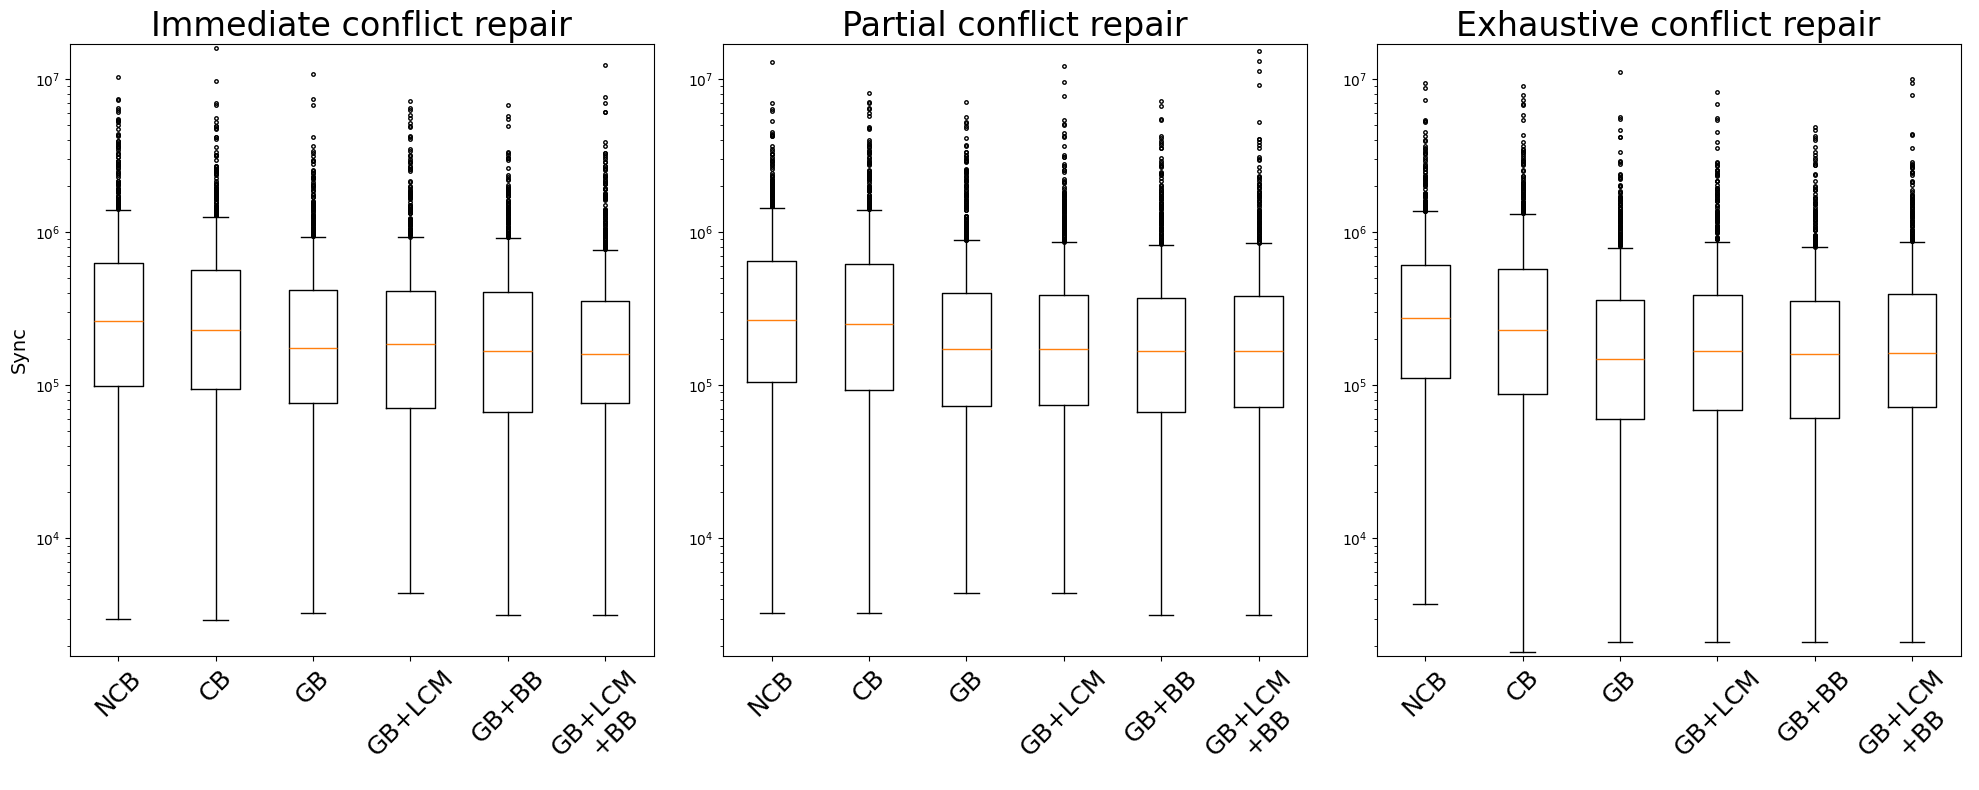

In [34]:
dataset = pd.read_csv(dataset_path)
# add the scaled down columns (divided by 1000, 1000000) if they exist
for col in dataset.columns:
    if col in ['file', 'option']:
        continue
    # if numeric column
    if pd.api.types.is_numeric_dtype(dataset[col]):
        if dataset[col].max() > 1000000:
            dataset[col + ' x10^6'] = dataset[col] / 1000000
        if dataset[col].max() > 1000:
            dataset[col + ' x10^3'] = dataset[col] / 1000

if "Time (ms) x10^3" in dataset.columns:
    dataset = dataset.rename(columns={"Time (ms) x10^3": "Time (s)"})

# dataset = dataset[dataset['option'].str.contains('--restarts off')]
# remove the --restarts off part from the option for better readability
dataset['option'] = dataset['option'].str.replace('--restarts off', '').str.strip()
options = dataset['option'].unique()

separated_default = { opt: dataset[dataset['option'] == opt] for opt in options if ('-pcr' not in opt and '-ecr' not in opt)}
separated_pcr     = { opt: dataset[dataset['option'] == opt] for opt in options if '-pcr' in opt}
separated_ecr     = { opt: dataset[dataset['option'] == opt] for opt in options if '-ecr' in opt}

for opt, data in separated_ecr.items():
    print(f"{opt}: {data['Sync'].mean():.2f} ± {data['Sync'].std():.2f}")

def sort_function(option) -> int:
    score = 0
    if "ECR" in option:
        score += 1000
    if "PCR" in option:
        score += 500
    if "CB" in option:
        score += 50
    if "NCB" in option:
        score += 50
    if "GB" in option:
        score -= 5
    if "LCM" in option:
        score -= 1
    if "BB" in option:
        score -= 10
    return -score

separated = {
    "Immediate conflict repair": separated_default,
    "Partial conflict repair": separated_pcr,
    "Exhaustive conflict repair": separated_ecr,
}

# remove the "-pcr" and "-ecr" from the option names for better readability
for name, sep in separated.items():
    for opt in list(sep.keys()):
        new_opt = opt.replace("-pcr", "").replace("-ecr", "").strip()
        new_opt = new_opt.replace("-ncb", "NCB").strip()
        new_opt = new_opt.replace("-rscb", "CB").strip()
        new_opt = new_opt.replace("-gb -lcm -bl", "GB+LCM").strip()
        new_opt = new_opt.replace("-gb -lcm", "GB+LCM\n+BB").strip()
        new_opt = new_opt.replace("-gb -bl", "GB").strip()
        new_opt = new_opt.replace("-gb", "GB+BB").strip()
        if new_opt != opt:
            separated[name][new_opt] = separated[name].pop(opt)


plt.figure(figsize=(20, 8))
for name, sep in separated.items():
    plt.subplot(1, 3, list(separated.keys()).index(name) + 1)
    data_to_plot = [sep[opt]['Sync'] for opt in sorted(sep.keys(), key=lambda x: sort_function(x))]
    plt.boxplot(data_to_plot, showfliers=True, flierprops=dict(marker='.', color='red', markersize=5))
    # plot a distribution plot
    # plt.violinplot(data_to_plot, showextrema='box', showmeans=True)
    # set the x ticks to the option names
    # increase the font of the ticks
    plt.xticks(fontsize=18)
    # center the option names if they contain a newline
    plt.xticks(rotation=45, ha='center')
    plt.xticks(range(1, len(sep.keys()) + 1), sorted(sep.keys(), key=lambda x: sort_function(x)))
    plt.title(name, fontsize=24)
    if name == "Immediate conflict repair":
        plt.ylabel("Sync", fontsize=14)
    plt.ylim(min(dataset['Sync']) * 0.95, max(dataset['Sync']) * 1.05)
    plt.yscale('log')
# plt.suptitle("Number of syncs depending on the configuration", fontsize=)
plt.tight_layout()
plt.savefig("/home/robin/papers/graph-backtracking/Figures/boxplot-"+dataset_path.split("/")[-1].replace(" ", "-").replace(".csv", "").lower()+".pdf")
plt.show()


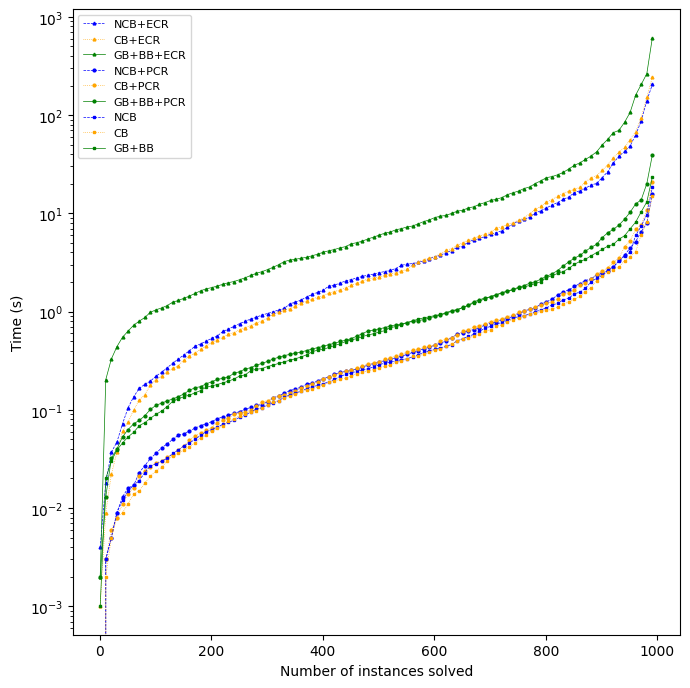

In [35]:
# create a cactus plot for each of the options
df = pd.read_csv(dataset_path)
df['Time (s)'] = df['Time (ms)'] / 1000

# remove the options -gb -lcm -bl, -gb -bl
df = df[~df['option'].str.contains('-gb -lcm -bl|-gb -bl|-gb -lcm')]

# rename the options for better readability
df['option'] = df['option'].str.replace('--restarts off', '').str.strip()
df['option'] = df['option'].str.replace('-ncb', 'NCB').str.strip()
df['option'] = df['option'].str.replace('-rscb', 'CB').str.strip()
df['option'] = df['option'].str.replace('-gb -lcm -bl', 'GB+LCM').str.strip()
df['option'] = df['option'].str.replace('-gb -lcm', 'GB+LCM+BB').str.strip()
df['option'] = df['option'].str.replace('-gb -bl', 'GB').str.strip()
df['option'] = df['option'].str.replace('-gb', 'GB+BB').str.strip()
df['option'] = df['option'].str.replace(' -ecr', '+ECR').str.strip()
df['option'] = df['option'].str.replace(' -pcr', '+PCR').str.strip()


plt.figure(figsize=(7, 7))
for option in sorted(df['option'].unique(), key=lambda x: sort_function(x)):
    dataset_option = df[df['option'] == option]
    dataset_option = dataset_option.sort_values(by=['Time (s)'])
    shape = 'o' if ('PCR' in option) else ('^' if 'ECR' in option else 's')
    color = 'blue' if ('NCB' in option) else ('orange' if 'CB' in option else 'green')
    # also add dashed and dotted lines for NCB and CB
    line_style = 'solid'
    if 'NCB' in option:
        line_style = 'dashed'
    elif 'CB' in option:
        line_style = 'dotted'

    x = range(1, len(dataset_option) + 1, 10)
    y = dataset_option['Time (s)'][::10]
    plt.plot(x, y, label=option, marker=shape, markersize=2, linewidth=0.5, color=color, linestyle=line_style)
plt.yscale('log')
plt.xlabel("Number of instances solved")
plt.ylabel("Time (s)")
# plt.title("Cactus plot of number of problems solved over time")
plt.legend(fontsize=8)
plt.tight_layout()
plt.savefig("/home/robin/papers/graph-backtracking/Figures/cactus-time-"+dataset_path.split("/")[-1].replace(" ", "-").replace(".csv", "").lower()+".pdf")
plt.show()

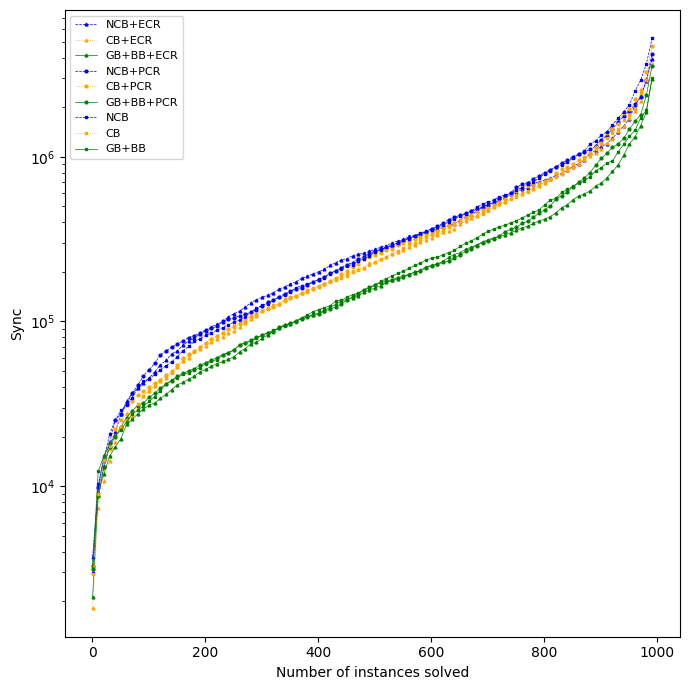

In [40]:
plt.figure(figsize=(7, 7))
for option in sorted(df['option'].unique(), key=lambda x: sort_function(x)):
    dataset_option = df[df['option'] == option]
    dataset_option = dataset_option.sort_values(by=['Sync'])
    shape = 'o' if ('PCR' in option) else ('^' if 'ECR' in option else 's')
    color = 'blue' if ('NCB' in option) else ('orange' if 'CB' in option else 'green')
    line_style = 'solid'
    if 'NCB' in option:
        line_style = 'dashed'
    elif 'CB' in option:
        line_style = 'dotted'

    x = range(1, len(dataset_option) + 1, 10)
    y = dataset_option['Sync'][::10]
    plt.plot(x, y, label=option, marker=shape, markersize=2, linewidth=0.5, color=color, linestyle=line_style)
plt.yscale('log')
plt.xlabel("Number of instances solved")
plt.ylabel("Sync")
# plt.title("Cactus plot of number of problems solved over syncs")
plt.legend(fontsize=8)
plt.tight_layout()
plt.savefig("/home/robin/papers/graph-backtracking/Figures/cactus-sync-"+dataset_path.split("/")[-1].replace(" ", "-").replace(".csv", "").lower()+".pdf")
plt.show()

['GB+BB' 'GB+BB+ECR' 'GB+BB+PCR' 'NCB' 'NCB+ECR' 'NCB+PCR' 'CB' 'CB+ECR'
 'CB+PCR']
NCB solved 1000 instances, GB solved 1000 instances, common: 1000 instances.


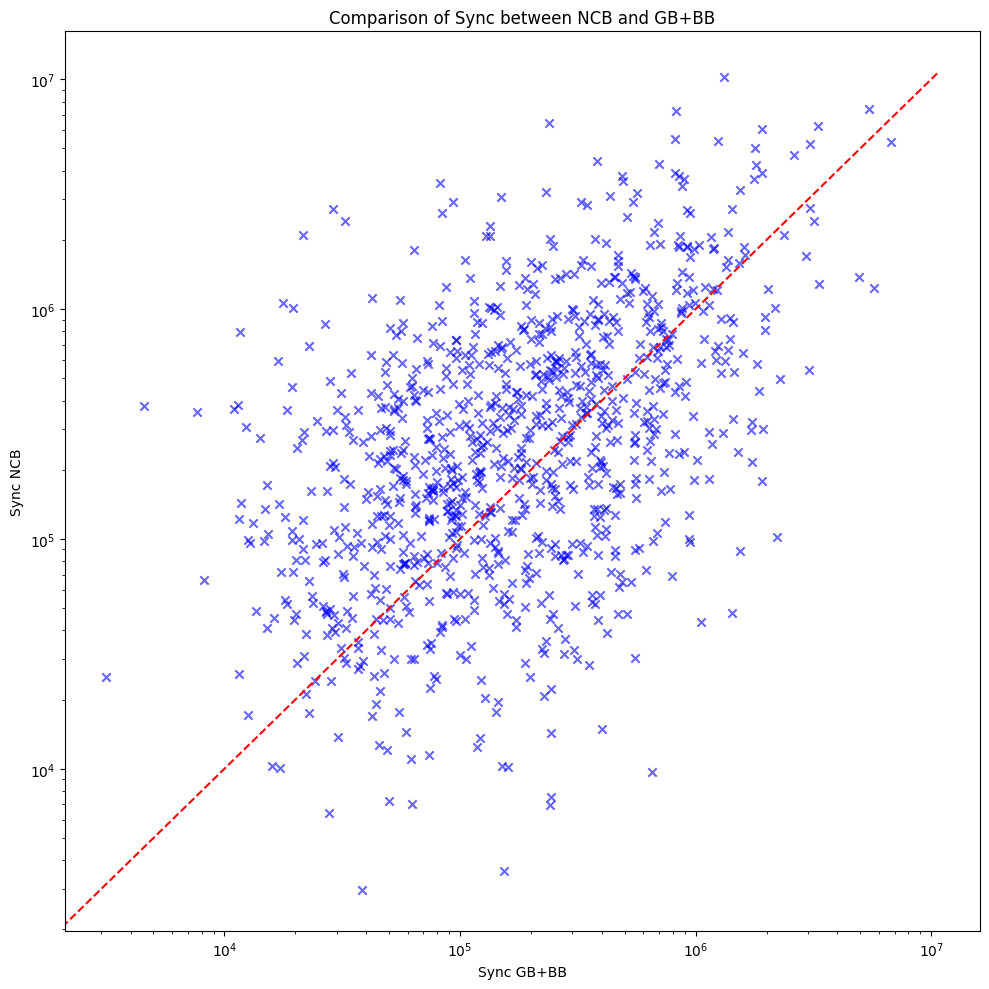

In [37]:
# scatter plot comparing NCB and GB
plt.figure(figsize=(10, 10))
print(df['option'].unique())
ncb_data = df[df['option'] == 'NCB'].sort_values(by=['file']).reset_index(drop=True)
gb_data = df[df['option'] == 'GB+BB'].sort_values(by=['file']).reset_index(drop=True)
# ensure that both dataframes have the same files
common_files = set(ncb_data['file']).intersection(set(gb_data['file']))
ncb_data = ncb_data[ncb_data['file'].isin(common_files)].reset_index(drop=True)
gb_data = gb_data[gb_data['file'].isin(common_files)].reset_index(drop=True)

print(f"NCB solved {len(ncb_data)} instances, GB solved {len(gb_data)} instances, common: {len(common_files)} instances.")

plt.scatter(gb_data['Sync'], ncb_data['Sync'], alpha=0.6, marker='x', color='blue', label='NCB vs GB+BB')
max_sync = max(max(gb_data['Sync']), max(ncb_data['Sync'])) * 1.05
plt.plot([0, max_sync], [0, max_sync], color='red', linestyle='--')
plt.xscale('log')
plt.yscale('log')
plt.xlabel("Sync GB+BB")
plt.ylabel("Sync NCB")
plt.title("Comparison of Sync between NCB and GB+BB")
plt.tight_layout()
plt.savefig("/home/robin/papers/graph-backtracking/Figures/scatter-ncb-gb-"+dataset_path.split("/")[-1].replace(" ", "-").replace(".csv", "").lower()+".pdf")
plt.show()


['GB+BB' 'GB+BB+ECR' 'GB+BB+PCR' 'NCB' 'NCB+ECR' 'NCB+PCR' 'CB' 'CB+ECR'
 'CB+PCR']
NCB solved 1000 instances, GB solved 1000 instances, common: 1000 instances.


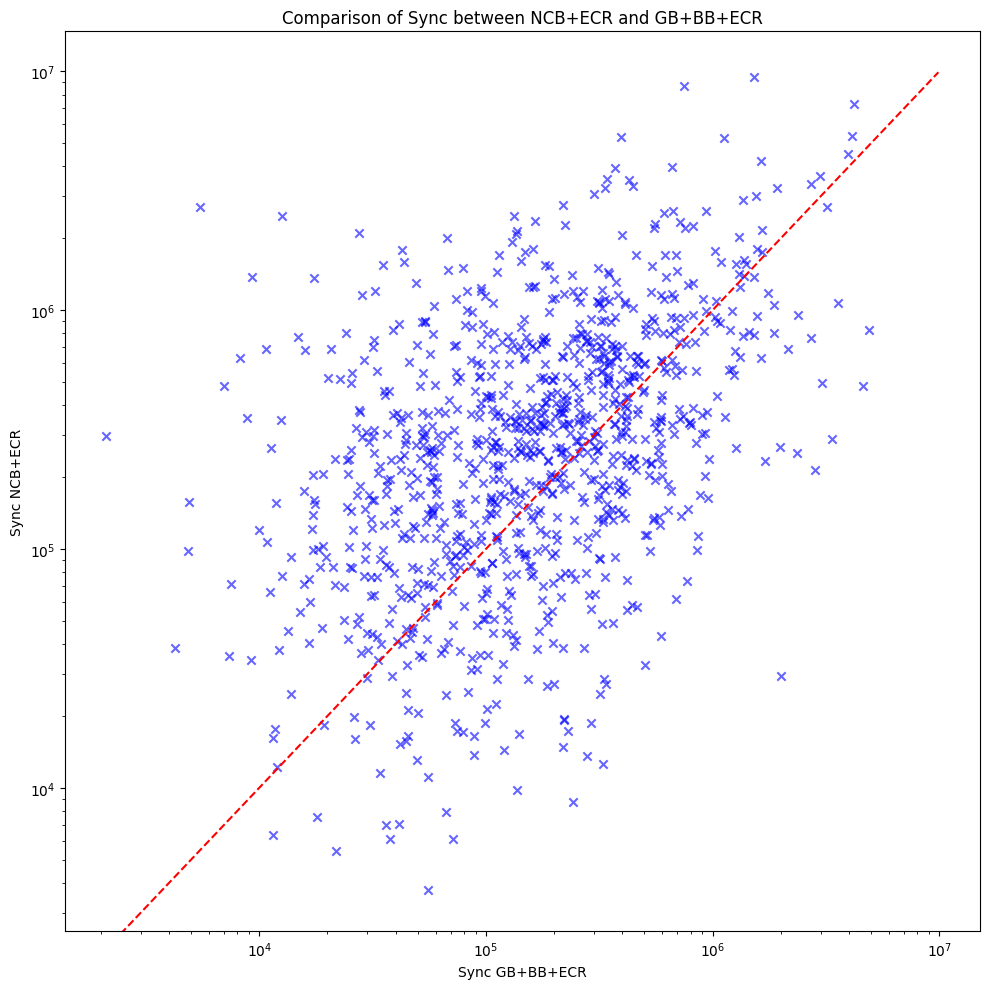

In [38]:
# scatter plot comparing NCB and GB
plt.figure(figsize=(10, 10))
print(df['option'].unique())
ncb_data = df[df['option'] == 'NCB+ECR'].sort_values(by=['file']).reset_index(drop=True)
gb_data = df[df['option'] == 'GB+BB+ECR'].sort_values(by=['file']).reset_index(drop=True)
# ensure that both dataframes have the same files
common_files = set(ncb_data['file']).intersection(set(gb_data['file']))
ncb_data = ncb_data[ncb_data['file'].isin(common_files)].reset_index(drop=True)
gb_data = gb_data[gb_data['file'].isin(common_files)].reset_index(drop=True)

print(f"NCB solved {len(ncb_data)} instances, GB solved {len(gb_data)} instances, common: {len(common_files)} instances.")

plt.scatter(gb_data['Sync'], ncb_data['Sync'], alpha=0.6, marker='x', color='blue', label='NCB vs GB+BB')
max_sync = max(max(gb_data['Sync']), max(ncb_data['Sync'])) * 1.05
plt.plot([0, max_sync], [0, max_sync], color='red', linestyle='--')
plt.xscale('log')
plt.yscale('log')
plt.xlabel("Sync GB+BB+ECR")
plt.ylabel("Sync NCB+ECR")
plt.title("Comparison of Sync between NCB+ECR and GB+BB+ECR")
plt.tight_layout()
plt.savefig("/home/robin/papers/graph-backtracking/Figures/scatter-ncb-gb-ecr-"+dataset_path.split("/")[-1].replace(" ", "-").replace(".csv", "").lower()+".pdf")
plt.show()

['GB+BB' 'GB+BB+ECR' 'GB+BB+PCR' 'NCB' 'NCB+ECR' 'NCB+PCR' 'CB' 'CB+ECR'
 'CB+PCR']
NCB solved 1000 instances, GB solved 1000 instances, common: 1000 instances.


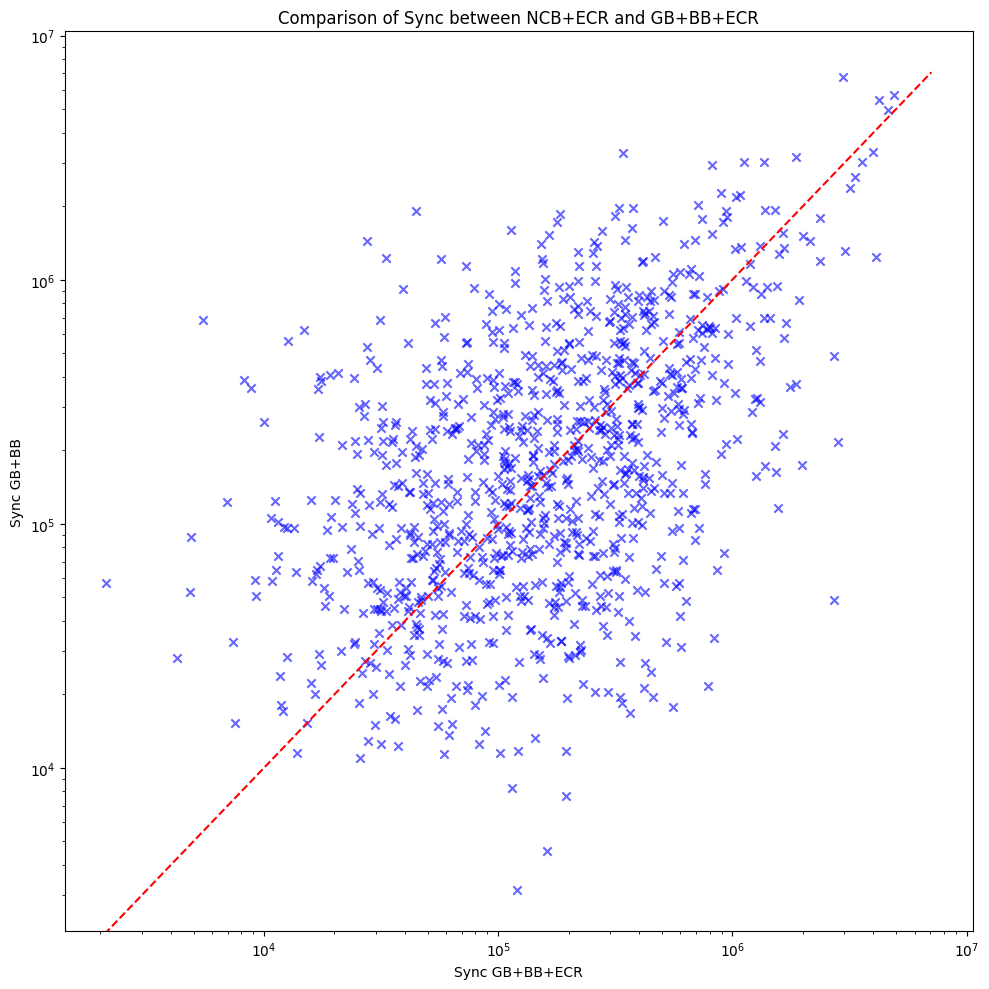

In [39]:
# scatter plot comparing NCB and GB
plt.figure(figsize=(10, 10))
print(df['option'].unique())
ncb_data = df[df['option'] == 'GB+BB'].sort_values(by=['file']).reset_index(drop=True)
gb_data = df[df['option'] == 'GB+BB+ECR'].sort_values(by=['file']).reset_index(drop=True)
# ensure that both dataframes have the same files
common_files = set(ncb_data['file']).intersection(set(gb_data['file']))
ncb_data = ncb_data[ncb_data['file'].isin(common_files)].reset_index(drop=True)
gb_data = gb_data[gb_data['file'].isin(common_files)].reset_index(drop=True)

print(f"NCB solved {len(ncb_data)} instances, GB solved {len(gb_data)} instances, common: {len(common_files)} instances.")

plt.scatter(gb_data['Sync'], ncb_data['Sync'], alpha=0.6, marker='x', color='blue', label='NCB vs GB+BB')
max_sync = max(max(gb_data['Sync']), max(ncb_data['Sync'])) * 1.05
plt.plot([0, max_sync], [0, max_sync], color='red', linestyle='--')
plt.xscale('log')
plt.yscale('log')
plt.xlabel("Sync GB+BB+ECR")
plt.ylabel("Sync GB+BB")
plt.title("Comparison of Sync between NCB+ECR and GB+BB+ECR")
plt.tight_layout()
# plt.savefig("/home/robin/papers/graph-backtracking/Figures/scatter-ncb-gb-ecr-"+dataset_path.split("/")[-1].replace(" ", "-").replace(".csv", "").lower()+".pdf")
plt.show()